# Ex. No. : 10 MINI-PROJECT
## E-Commerce Customer Segmentation using K-Means Clustering

**PROBLEM STATEMENT:**
Write a program to implement E-Commerce Customer Segmentation using the K-Means clustering algorithm. The customer data is analyzed using annual income and spending score to group customers into meaningful segments.

**AIM:**
To implement E-Commerce Customer Segmentation using K-Means clustering and identify different groups of customers based on their purchasing characteristics.

**DATASET:**
The Mall Customers dataset is used. It contains 200 customer records with CustomerID, Age, Annual Income (k\$), and Spending Score (1-100). The clustering features are Annual Income (k\$) and Spending Score (1-100).

### PROCEDURE:
Step 1: Import the required libraries.
Step 2: Load the customer segmentation dataset.
Step 3: Explore the dataset and check for missing values.
Step 4: Select Annual Income (k\$) and Spending Score (1-100) as clustering features.
Step 5: Plot the original customer data.
Step 6: Use the Elbow Method to determine a suitable value of K.
Step 7: Apply K-Means clustering with K = 5.
Step 8: Assign a cluster ID to every customer.
Step 9: Display the cluster centres and segmented customer records.
Step 10: Plot the final customer clusters and cluster-wise customer count.

### PROGRAM:
**Importing Libraries**

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

**Load Dataset & Explore**

In [2]:
# Load Dataset
data = pd.read_csv('Mall_Customers.csv')
print(data.head())
print(data.shape)

# Explore the dataset
print(data.info())
print(data.isnull().sum())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Genre         

**SELECTING FEATURES**

In [3]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


**ELBOW METHOD**

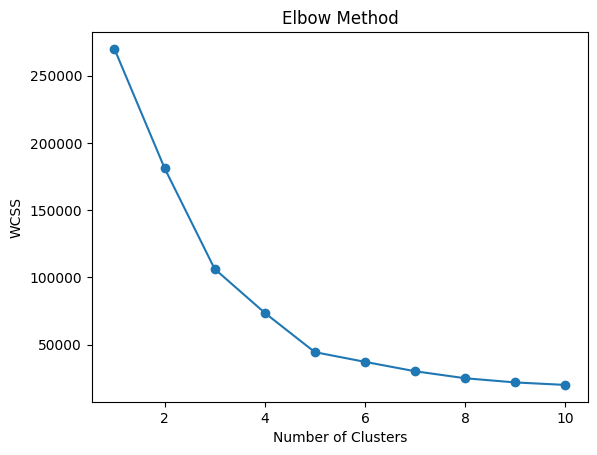

In [4]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

**APPLYING K-MEANS ALGORITHM**

In [5]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(X)
print(data['Cluster'].head(20))

0     4
1     2
2     4
3     2
4     4
5     2
6     4
7     2
8     4
9     2
10    4
11    2
12    4
13    2
14    4
15    2
16    4
17    2
18    4
19    2
Name: Cluster, dtype: int32


**CLUSTER CENTRES & CUSTOMER SEGMENTATION GRAPH**

Cluster Centres:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


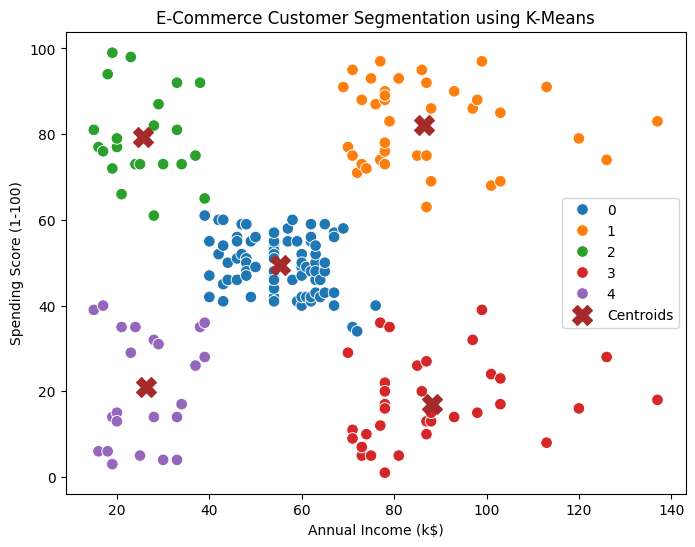

In [6]:
print('Cluster Centres:')
print(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', s=70, palette='tab10')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, marker='X', color='brown', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('E-Commerce Customer Segmentation using K-Means')
plt.legend()
plt.show()

**CLUSTER-WISE CUSTOMER COUNT**

In [7]:
print(data['Cluster'].value_counts().sort_index())

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


**FINAL SEGMENTED CUSTOMER OUTPUT**

In [8]:
print(data[['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head(20))

    CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0            1   19                  15                      39        4
1            2   21                  15                      81        2
2            3   20                  16                       6        4
3            4   23                  16                      77        2
4            5   31                  17                      40        4
5            6   22                  17                      76        2
6            7   35                  18                       6        4
7            8   23                  18                      94        2
8            9   64                  19                       3        4
9           10   30                  19                      72        2
10          11   67                  19                      14        4
11          12   35                  19                      99        2
12          13   58                  20            

### RESULT:
Thus the E-Commerce Customer Segmentation using the K-Means clustering algorithm was implemented successfully. The 200 customer records were grouped into five clusters based on Annual Income and Spending Score, and the corresponding Cluster ID was obtained for each customer.

### OBSERVATION:
* Cluster 0 contains the largest group of customers in this run.
* Cluster 1 represents customers with relatively high income and high spending score.
* Cluster 2 represents customers with relatively low income and high spending score.
* Cluster 3 represents customers with relatively high income and low spending score.
* Cluster 4 represents customers with relatively low income and low spending score.
* Cluster numbers are labels generated by K-Means; they do not themselves indicate a fixed rank.

### CONCLUSION:
The K-Means clustering model successfully segments e-commerce customers into five groups. The resulting clusters can be used to understand customer behaviour and support targeted marketing and customer relationship strategies.